1.Consider the lung cancer data and solve the following questions using Python.
Basic EDA Questions i) Summarize the distribution of Age. Is it normally distributed or skewed? ii) What proportion of individuals are smokers vs non-smokers? iii) Which income group has the highest frequency? iv) What percentage of individuals are exposed to high pollution? v) What is the overall prevalence of lung disease?

Association & Crosstab i) Is there an association between Smoking and Lung Disease? ii) Interpret using a contingency table. iii) Does Pollution level affect Lung Disease? iv) Compare lung disease prevalence across Income groups. v) Which factor appears to have the strongest relationship with lung disease?

Statistical Testing i) Perform a Chi-square test for: Smoking vs Lung Disease and Pollution vs Lung Disease. ii) When should you use Fisher's Exact Test instead of Chi-square? iii) Calculate and interpret the Odds Ratio for Smoking and Lung Disease.

Correlation & Interpretation i) Interpret the correlation between: Smoking and Lung Disease, Age and Lung Disease. ii) Why is correlation not sufficient for causal inference?

Logistic Regression i) Fit a logistic regression model: Lung Disease ~ Smoking + Age + Pollution + Income. ii) Which variables are statistically significant predictors? ii) Interpret the odds ratio of Smoking. iii) What happens to the effect of Smoking after adjusting for Pollution?

Advanced Modeling i) Add an interaction term (Smoking x Pollution). ii) Is the interaction significant? iii) Interpret the interaction: Does pollution amplify smoking risk?

Research question: using the lung disease dataset,perform exploratory data analysis ans fit a logistic regression model to identify key determinants of lung disease. interpret your finds and discuss public health implications. now give solution using python


--- Age Distribution ---
Mean Age : 43.90
SD Age   : 14.60
Skewness : 0.0121


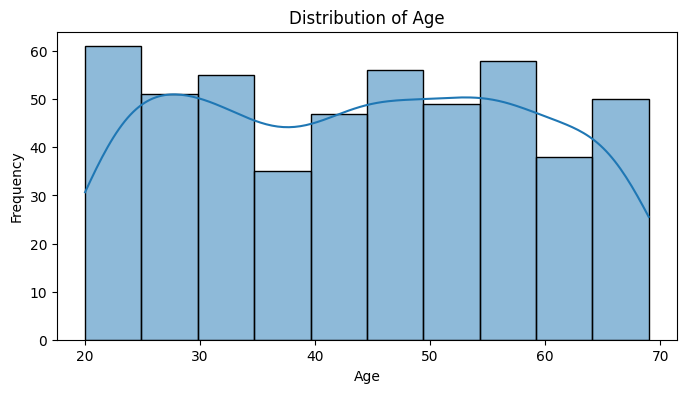


--- Smoking Proportion ---
Smoking
No     58.6
Yes    41.4
Name: proportion, dtype: float64

Income group with highest frequency:
Low

High Pollution Percentage: 70.40%

Overall Lung Disease Prevalence: 52.80%

--- Contingency Table ---
LungDisease   No  Yes
Smoking              
No           184  109
Yes           52  155

--- Chi-square Test ---
Chi-square Statistic : 67.5943
P-value              : 0.000000
Significant association exists.

Pollution P-value: 0.000000

--- Fisher Exact Test ---
Odds Ratio : 5.03
P-value    : 0.000000

Odds Ratio for Smoking: 5.03
Optimization terminated successfully.
         Current function value: 0.552949
         Iterations 6

--- Logistic Regression Model ---
                           Logit Regression Results                           
Dep. Variable:     LungDisease_binary   No. Observations:                  500
Model:                          Logit   Df Residuals:                      494
Method:                           MLE   Df Model:     

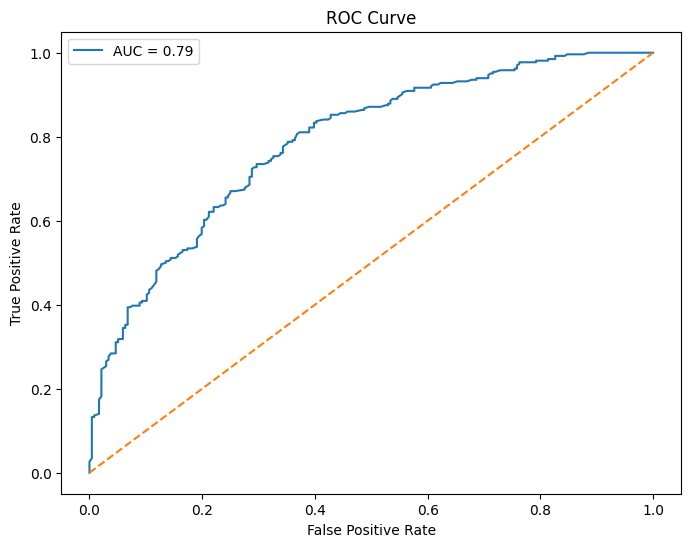


AUC Score: 0.79

--- Confusion Matrix ---
[[156  80]
 [ 64 200]]

Accuracy:
0.712

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.66      0.68       236
           1       0.71      0.76      0.74       264

    accuracy                           0.71       500
   macro avg       0.71      0.71      0.71       500
weighted avg       0.71      0.71      0.71       500



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

from scipy.stats import chi2_contingency, fisher_exact
from sklearn.metrics import (
    roc_curve,
    auc,
    confusion_matrix,
    classification_report,
    accuracy_score
)

# 1. Load Data

df = pd.read_csv("lung_disease.csv")

# 2. Data Pre-processing

# Convert categorical variables into binary
df['Smoking_binary'] = df['Smoking'].map({'Yes': 1, 'No': 0})
df['LungDisease_binary'] = df['LungDisease'].map({'Yes': 1, 'No': 0})
df['Pollution_binary'] = df['Pollution'].map({'High': 1, 'Low': 0})

# BASIC EDA

# i) Age Distribution
print("\n--- Age Distribution ---")
print(f"Mean Age : {df['Age'].mean():.2f}")
print(f"SD Age   : {df['Age'].std():.2f}")
print(f"Skewness : {df['Age'].skew():.4f}")

plt.figure(figsize=(8,4))
sns.histplot(df['Age'], kde=True)
plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

# ii) Smoking Proportion
print("\n--- Smoking Proportion ---")
print(df['Smoking'].value_counts(normalize=True) * 100)

# iii) Income Frequency
print("\nIncome group with highest frequency:")
print(df['Income'].mode()[0])

# iv) Pollution Exposure
pollution_percent = (df['Pollution'] == 'High').mean() * 100
print(f"\nHigh Pollution Percentage: {pollution_percent:.2f}%")

# v) Lung Disease Prevalence
disease_prev = df['LungDisease_binary'].mean() * 100
print(f"\nOverall Lung Disease Prevalence: {disease_prev:.2f}%")

# ASSOCIATION & CROSSTAB

# Smoking vs Lung Disease
smoking_ct = pd.crosstab(df['Smoking'], df['LungDisease'])

print("\n--- Contingency Table ---")
print(smoking_ct)

# STATISTICAL TESTING

# i) Chi-square Test
chi2_smok, p_smok, dof, expected = chi2_contingency(smoking_ct)

print("\n--- Chi-square Test ---")
print(f"Chi-square Statistic : {chi2_smok:.4f}")
print(f"P-value              : {p_smok:.6f}")

if p_smok < 0.05:
    print("Significant association exists.")
else:
    print("No significant association.")

# Pollution vs Lung Disease
poll_ct = pd.crosstab(df['Pollution'], df['LungDisease'])

chi2_poll, p_poll, _, _ = chi2_contingency(poll_ct)

print(f"\nPollution P-value: {p_poll:.6f}")

# ii) Fisher Exact Test

if smoking_ct.shape == (2,2):
    odds_fisher, p_fisher = fisher_exact(smoking_ct)

    print("\n--- Fisher Exact Test ---")
    print(f"Odds Ratio : {odds_fisher:.2f}")
    print(f"P-value    : {p_fisher:.6f}")

# iii) Odds Ratio

a = smoking_ct.iloc[1,1]
b = smoking_ct.iloc[1,0]
c = smoking_ct.iloc[0,1]
d = smoking_ct.iloc[0,0]

odds_ratio = (a*d)/(b*c)

print(f"\nOdds Ratio for Smoking: {odds_ratio:.2f}")

# LOGISTIC REGRESSION

model = smf.logit(
    'LungDisease_binary ~ Smoking_binary + Age + Pollution_binary + C(Income)',
    data=df
).fit()

print("\n--- Logistic Regression Model ---")
print(model.summary())

# Odds Ratios
print("\nOdds Ratios:")
print(np.exp(model.params))

# ADVANCED MODELING

interaction_model = smf.logit(
    'LungDisease_binary ~ Smoking_binary * Pollution_binary + Age + C(Income)',
    data=df
).fit()

print("\n--- Interaction Model ---")
print(interaction_model.summary())

# MODEL EVALUATION

# Predicted probabilities
y_prob = model.predict(df)

# Predicted class
y_pred = (y_prob > 0.5).astype(int)

# i) ROC Curve and AUC
fpr, tpr, threshold = roc_curve(df['LungDisease_binary'], y_prob)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

print(f"\nAUC Score: {roc_auc:.2f}")

# iii) Confusion Matrix

cm = confusion_matrix(df['LungDisease_binary'], y_pred)

print("\n--- Confusion Matrix ---")
print(cm)

print("\nAccuracy:")
print(accuracy_score(df['LungDisease_binary'], y_pred))

print("\nClassification Report:")
print(classification_report(df['LungDisease_binary'], y_pred))

Research question:
using the lung disease dataset,perform exploratory data analysis ans fit a logistic regression model to identify key determinants of lung disease. interpret your finds and discuss public health implications. now give solution using python


--- Summary Statistics ---
                ID Smoking         Age Income Pollution LungDisease  \
count   500.000000     500  500.000000    500       500         500   
unique         NaN       2         NaN      3         2           2   
top            NaN      No         NaN    Low      High         Yes   
freq           NaN     293         NaN    204       352         264   
mean    250.500000     NaN   43.904000    NaN       NaN         NaN   
std     144.481833     NaN   14.604841    NaN       NaN         NaN   
min       1.000000     NaN   20.000000    NaN       NaN         NaN   
25%     125.750000     NaN   30.750000    NaN       NaN         NaN   
50%     250.500000     NaN   45.000000    NaN       NaN         NaN   
75%     375.250000     NaN   56.000000    NaN       NaN         NaN   
max     500.000000     NaN   69.000000    NaN       NaN         NaN   

        LungDisease_num  Smoking_num  
count        500.000000   500.000000  
unique              NaN          NaN  
to

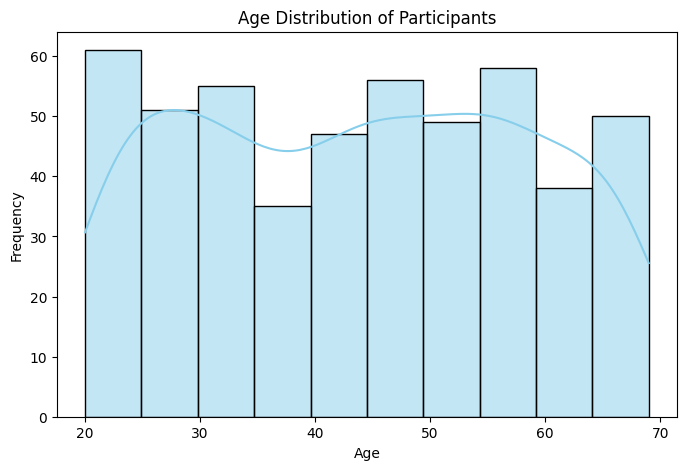

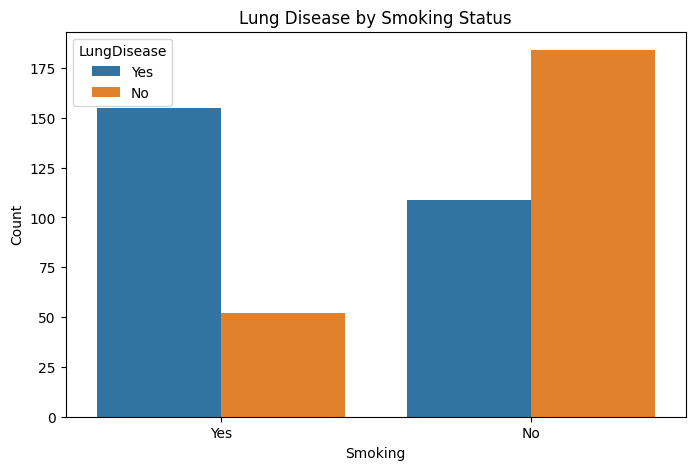

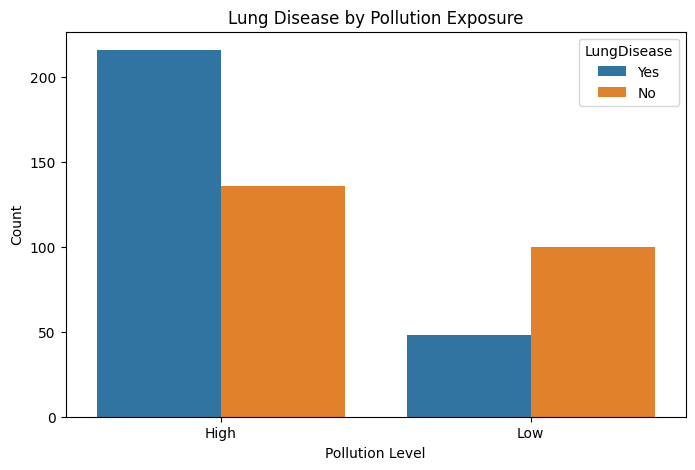

Optimization terminated successfully.
         Current function value: 0.552949
         Iterations 6

--- Logistic Regression Summary ---
                           Logit Regression Results                           
Dep. Variable:        LungDisease_num   No. Observations:                  500
Model:                          Logit   Df Residuals:                      494
Method:                           MLE   Df Model:                            5
Date:                Tue, 19 May 2026   Pseudo R-squ.:                  0.2005
Time:                        05:34:29   Log-Likelihood:                -276.47
converged:                       True   LL-Null:                       -345.79
Covariance Type:            nonrobust   LLR p-value:                 3.499e-28
                                                       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------------

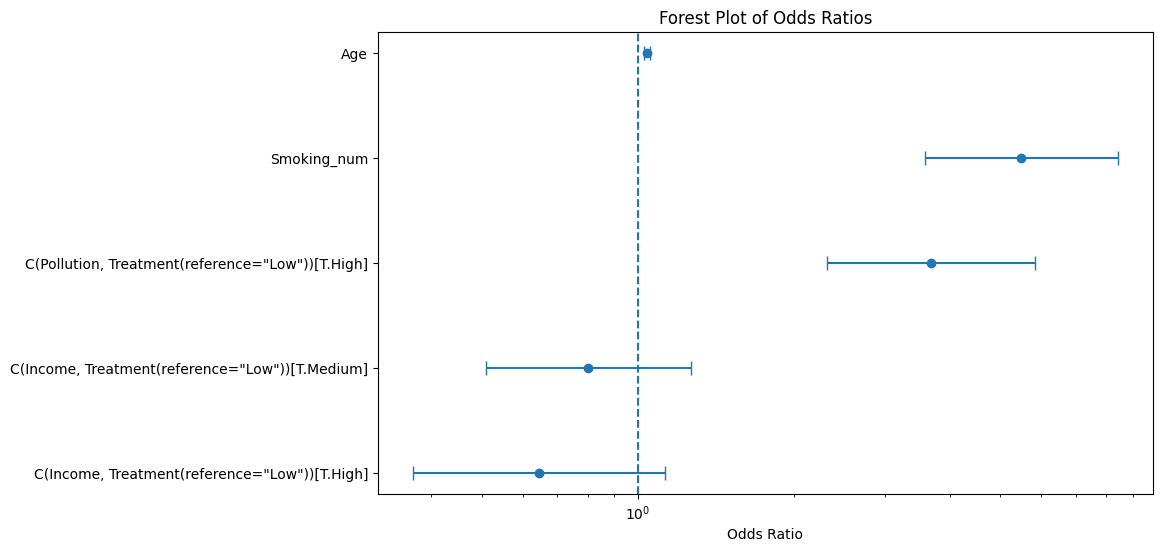


Interpretation:

1. Odds Ratio > 1:
   Predictor increases the chance of lung disease.

2. Odds Ratio < 1:
   Predictor decreases the chance of lung disease.

3. If p-value < 0.05:
   Predictor is statistically significant.

4. Confidence interval crossing 1 means:
   Predictor may not be significant.


Analysis Complete.


In [ ]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load Dataset

df = pd.read_csv('lung_disease.csv')

# 2. Data Preprocessing

# Convert Yes/No variables into numeric
df['LungDisease_num'] = df['LungDisease'].map({'Yes': 1, 'No': 0})
df['Smoking_num'] = df['Smoking'].map({'Yes': 1, 'No': 0})

# EXPLORATORY DATA ANALYSIS (EDA)

# Summary Statistics
print("\n--- Summary Statistics ---")
print(df.describe(include='all'))

# Age Distribution Plot

plt.figure(figsize=(8,5))

sns.histplot(
    df['Age'],
    kde=True,
    color='skyblue'
)

plt.title('Age Distribution of Participants')
plt.xlabel('Age')
plt.ylabel('Frequency')

plt.show()

# Smoking vs Lung Disease

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='Smoking',
    hue='LungDisease'
)

plt.title('Lung Disease by Smoking Status')
plt.xlabel('Smoking')
plt.ylabel('Count')

plt.show()

# Pollution vs Lung Disease

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='Pollution',
    hue='LungDisease'
)

plt.title('Lung Disease by Pollution Exposure')
plt.xlabel('Pollution Level')
plt.ylabel('Count')

plt.show()

# LOGISTIC REGRESSION MODEL

# Logistic Regression Formula
formula = '''
LungDisease_num ~
Smoking_num +
Age +
C(Income, Treatment(reference="Low")) +
C(Pollution, Treatment(reference="Low"))
'''

# Fit Logistic Regression Model
model = smf.logit(formula, data=df).fit()

# Model Summary

print("\n--- Logistic Regression Summary ---")
print(model.summary())

# Odds Ratios & Confidence Intervals

# Odds Ratios
odds_ratio = np.exp(model.params)

# Confidence Intervals
conf_int = np.exp(model.conf_int())

# Combine Results
results = pd.concat([odds_ratio, conf_int], axis=1)

results.columns = [
    'Odds Ratio',
    'Lower 95% CI',
    'Upper 95% CI'
]

print("\n--- Odds Ratios ---")
print(results)

# Forest Plot for Odds Ratios

# Remove intercept for plotting
plot_data = results.drop('Intercept')

plt.figure(figsize=(10,6))

plt.errorbar(
    plot_data['Odds Ratio'],
    range(len(plot_data)),
    xerr=[
        plot_data['Odds Ratio'] - plot_data['Lower 95% CI'],
        plot_data['Upper 95% CI'] - plot_data['Odds Ratio']
    ],
    fmt='o',
    capsize=5
)

# Reference line
plt.axvline(x=1, linestyle='--')

# Labels
plt.yticks(range(len(plot_data)), plot_data.index)

plt.xlabel('Odds Ratio')
plt.title('Forest Plot of Odds Ratios')

# Log scale
plt.xscale('log')

plt.show()

# Interpretation

print("\nInterpretation:")

print("""
1. Odds Ratio > 1:
   Predictor increases the chance of lung disease.

2. Odds Ratio < 1:
   Predictor decreases the chance of lung disease.

3. If p-value < 0.05:
   Predictor is statistically significant.

4. Confidence interval crossing 1 means:
   Predictor may not be significant.
""")

print("\nAnalysis Complete.")

Suppose we want to determine if three different exercise programs impact weight loss differently. We recruit 90 people to participate in an experiment in which we randomly assign (using uniform distribution) 30 people to follow either program A, program B, or program C for one month. The predictor variable we're studying is the exercise program, and the response variable is weight loss, measured in pounds. Conduct a one-way ANOVA to determine if there is a statistically significant difference between the resulting weight loss from the three programs, check the model assumptions, and analyze treatment differences.


--- First 5 Observations ---
  Program  WeightLoss
0       A    5.745071
1       A    4.792604
2       A    5.971533
3       A    7.284545
4       A    4.648770

--- Summary Statistics ---
             mean       std       min       max
Program                                        
A        4.717780  1.350010  2.130080  7.368819
B        6.818256  1.396653  4.060495  9.778417
C        5.519327  1.487975  1.570382  7.846965

--- ANOVA Table ---
                sum_sq    df          F        PR(>F)
C(Program)   67.416974   2.0  16.890178  6.342321e-07
Residual    173.629808  87.0        NaN           NaN

--- Shapiro-Wilk Test ---
Statistic : 0.9925
P-value   : 0.8948
Residuals are approximately normal.

--- Levene Test ---
Statistic : 0.1480
P-value   : 0.8627
Equal variance assumption satisfied.

--- Tukey HSD Test ---


/tmp/ipykernel_1787/963339880.py:105: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if anova_table['PR(>F)'][0] < 0.05:


Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
     A      B   2.1005    0.0  1.2307  2.9702   True
     A      C   0.8015 0.0772 -0.0682  1.6713  False
     B      C  -1.2989 0.0017 -2.1687 -0.4292   True
----------------------------------------------------


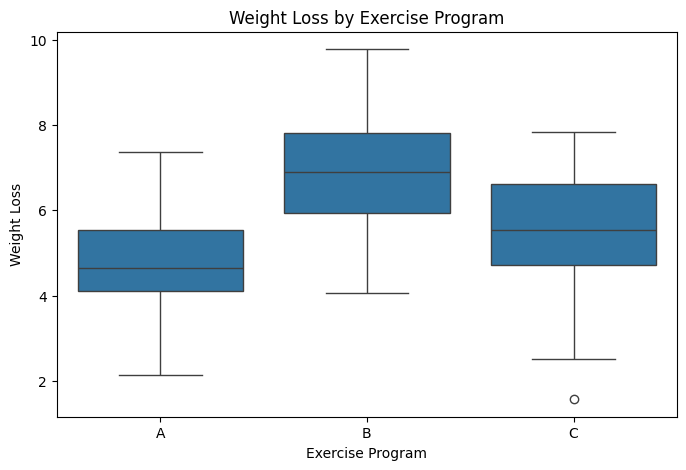

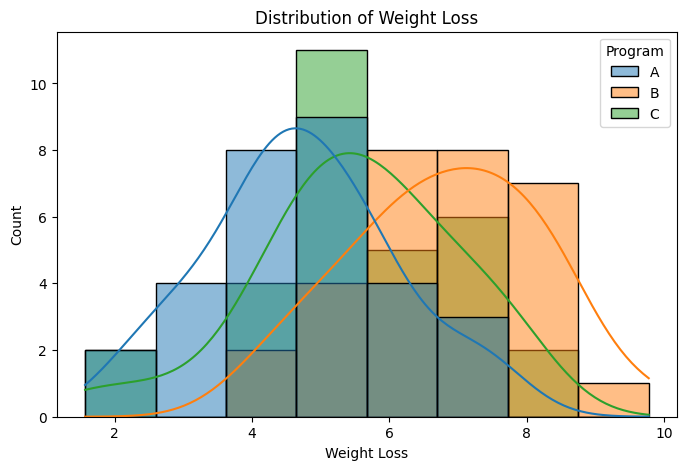


--- Interpretation ---

There is a significant difference in mean weight loss
among the exercise programs.

The Tukey HSD test identifies which programs differ.


Analysis Complete.


/tmp/ipykernel_1787/963339880.py:161: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if anova_table['PR(>F)'][0] < 0.05:


In [ ]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import statsmodels.api as sm

from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd

import matplotlib.pyplot as plt
import seaborn as sns

# 1. Generate Dataset

np.random.seed(42)

n = 30

data = pd.DataFrame({

    'Program': ['A'] * n + ['B'] * n + ['C'] * n,

    'WeightLoss': np.concatenate([

        np.random.normal(5, 1.5, n),     # Program A
        np.random.normal(7, 1.5, n),     # Program B
        np.random.normal(5.5, 1.5, n)    # Program C
    ])
})

# 2. Display First Rows

print("\n--- First 5 Observations ---")
print(data.head())

# 3. Descriptive Statistics

print("\n--- Summary Statistics ---")

summary = data.groupby('Program')['WeightLoss'].agg([
    'mean',
    'std',
    'min',
    'max'
])

print(summary)

# 4. One-Way ANOVA

model = ols('WeightLoss ~ C(Program)', data=data).fit()

anova_table = sm.stats.anova_lm(model, typ=2)

print("\n--- ANOVA Table ---")
print(anova_table)

# 5. Assumption Checking

# i) Normality Test
shapiro_stat, shapiro_p = stats.shapiro(model.resid)

print("\n--- Shapiro-Wilk Test ---")
print(f"Statistic : {shapiro_stat:.4f}")
print(f"P-value   : {shapiro_p:.4f}")

if shapiro_p > 0.05:
    print("Residuals are approximately normal.")
else:
    print("Residuals are not normally distributed.")

# -----------------------------------------

# ii) Homogeneity of Variance
levene_stat, levene_p = stats.levene(

    data[data['Program'] == 'A']['WeightLoss'],
    data[data['Program'] == 'B']['WeightLoss'],
    data[data['Program'] == 'C']['WeightLoss']

)

print("\n--- Levene Test ---")
print(f"Statistic : {levene_stat:.4f}")
print(f"P-value   : {levene_p:.4f}")

if levene_p > 0.05:
    print("Equal variance assumption satisfied.")
else:
    print("Variance assumption violated.")

# 6. Post Hoc Test (Tukey HSD)

if anova_table['PR(>F)'][0] < 0.05:

    print("\n--- Tukey HSD Test ---")

    tukey = pairwise_tukeyhsd(

        endog=data['WeightLoss'],
        groups=data['Program'],
        alpha=0.05

    )

    print(tukey)

# 7. Visualization

# Boxplot
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Program',
    y='WeightLoss',
    data=data
)

plt.title('Weight Loss by Exercise Program')
plt.xlabel('Exercise Program')
plt.ylabel('Weight Loss')

plt.show()


# Histogram
plt.figure(figsize=(8,5))

sns.histplot(
    data=data,
    x='WeightLoss',
    hue='Program',
    kde=True
)

plt.title('Distribution of Weight Loss')
plt.xlabel('Weight Loss')

plt.show()

# 8. Interpretation

print("\n--- Interpretation ---")

if anova_table['PR(>F)'][0] < 0.05:

    print("""
There is a significant difference in mean weight loss
among the exercise programs.

The Tukey HSD test identifies which programs differ.
""")

else:

    print("""
No significant difference exists among the exercise programs.
""")

print("\nAnalysis Complete.")

Problem 3:Consider the Anemia Levels in Nigeria dataset: (https://www.kaggle.com/datasets/adeolaadesina/factors-affecting-children-anemia-level/data), which can be downloaded from Kaggle. The dataset comes from the 2018 Nigeria Demographic and Health Surveys (NDHS). It explores the impact of mothers' age and socioeconomic factors on anemia levels among children aged 0-59 months across Nigeria's 36 states and the Federal Capital Territory. Based on the above data, create a contingency table, apply chi-square test, formulate hypothesis, create a contribution diagram, and interpret the findings.

Chi-Square Statistic: 203.55
P-value: 6.0173e-37
Degrees of Freedom: 12

Percentage of Anemia Category by Wealth Index:
Anemia level            Mild  Moderate  Not anemic  Severe
Wealth index combined                                     
Middle                 26.50     27.57       44.32    1.61
Poorer                 27.87     31.92       38.46    1.75
Poorest                28.98     35.55       33.39    2.09
Richer                 25.97     24.40       47.51    2.12
Richest                23.05     16.38       59.62    0.95


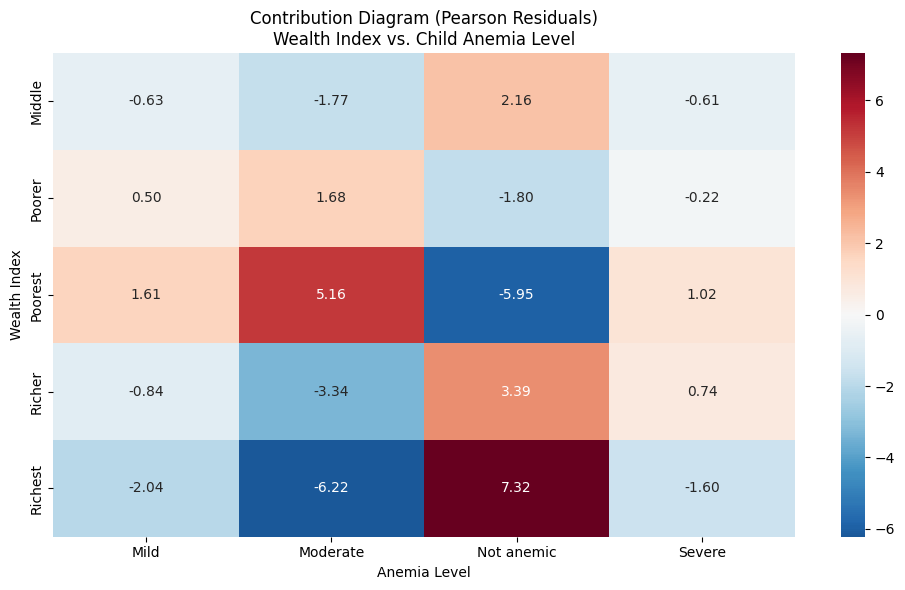

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

# 1. Load and Clean Data
df = pd.read_csv('children anemia.csv')

# Drop missing values specifically for the variables of interest
# We use Wealth Index as the socioeconomic factor and Anemia level as the outcome
clean_df = df.dropna(subset=['Wealth index combined', 'Anemia level'])

# 2. Create Contingency Table
# This fulfills: "create a contingency table"
contingency_table = pd.crosstab(clean_df['Wealth index combined'], clean_df['Anemia level'])

# 3. Apply Chi-Square Test
# This fulfills: "apply chi-square test"
chi2, p_val, dof, expected = chi2_contingency(contingency_table)

# 4. Create a Contribution Diagram (Pearson Residuals)
# Pearson Residuals indicate which cells contribute most to the Chi-square statistic
# Formula: (Observed - Expected) / sqrt(Expected)
residuals = (contingency_table - expected) / np.sqrt(expected)

# --- Output Results ---
print(f"Chi-Square Statistic: {chi2:.2f}")
print(f"P-value: {p_val:.4e}")
print(f"Degrees of Freedom: {dof}")

# 5. Visualization - Contribution Diagram Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(residuals, annot=True, cmap='RdBu_r', center=0, fmt='.2f')
plt.title('Contribution Diagram (Pearson Residuals)\nWealth Index vs. Child Anemia Level')
plt.xlabel('Anemia Level')
plt.ylabel('Wealth Index')
plt.tight_layout()
plt.savefig('anemia_contribution_diagram.png')

# Summary of row percentages for easier interpretation
wealth_proportions = contingency_table.div(contingency_table.sum(axis=1), axis=0) * 100
print("\nPercentage of Anemia Category by Wealth Index:")
print(wealth_proportions.round(2))

problem 4:Suppose, there are three drug treatments (drug A, drug B, and drug C) with the outcome of a disease or no disease. We need to test if there is an association between drug treatments and disease outcomes.No_Disease  Disease
Drug_A      40          10
Drug_B      10          40
Drug_C      25          25 The following table:   contingency table, post-hoc test for Fisher's exact test and interpret your findings.

In [ ]:
import numpy as np
import pandas as pd

from scipy.stats import chi2_contingency, fisher_exact
from statsmodels.stats.multitest import multipletests

# 1. Create Contingency Table

table = np.array([

    [40, 10],   # Drug A
    [10, 40],   # Drug B
    [25, 25]    # Drug C

])

# Drug names
drugs = ['Drug A', 'Drug B', 'Drug C']

# Convert to DataFrame
df = pd.DataFrame(

    table,
    index=drugs,
    columns=['Recovered', 'Not Recovered']

)

print("\n--- Contingency Table ---")
print(df)

# 2. Chi-Square Test

chi2_stat, p_global, dof, expected = chi2_contingency(table)

print("\n--- Global Chi-Square Test ---")

print(f"Chi-Square Statistic : {chi2_stat:.4f}")
print(f"P-value              : {p_global:.6f}")
print(f"Degrees of Freedom   : {dof}")

# Expected frequencies
expected_df = pd.DataFrame(

    expected,
    index=drugs,
    columns=['Recovered', 'Not Recovered']

)

print("\n--- Expected Frequencies ---")
print(expected_df.round(2))

# Interpretation
if p_global < 0.05:

    print("\nThere is a significant association")
    print("between Drug Type and Recovery Status.")

else:

    print("\nNo significant association exists")
    print("between Drug Type and Recovery Status.")

# 3. Pairwise Fisher Exact Tests

pairs = [

    (0, 1),
    (0, 2),
    (1, 2)

]

pair_names = [

    ('Drug A', 'Drug B'),
    ('Drug A', 'Drug C'),
    ('Drug B', 'Drug C')

]

p_values = []

print("\n--- Pairwise Fisher Exact Tests ---")

for i, j in pairs:

    # Create 2x2 table
    pair_table = table[[i, j]]

    # Fisher Exact Test
    odds_ratio, p_pair = fisher_exact(pair_table)

    p_values.append(p_pair)

# 4. Bonferroni Correction

reject, p_adjusted, _, _ = multipletests(

    p_values,
    alpha=0.05,
    method='bonferroni'

)

# 5. Display Pairwise Results

results = pd.DataFrame({

    'Comparison': [
        'Drug A vs Drug B',
        'Drug A vs Drug C',
        'Drug B vs Drug C'
    ],

    'Original P-value': p_values,
    'Adjusted P-value': p_adjusted,
    'Significant': reject

})

print(results)

# 6. Odds Ratio for Pairwise Tests

print("\n--- Odds Ratios ---")

for idx, (i, j) in enumerate(pairs):

    pair_table = table[[i, j]]

    odds_ratio, p_pair = fisher_exact(pair_table)

    print(f"{pair_names[idx][0]} vs {pair_names[idx][1]}")

    print(f"Odds Ratio : {odds_ratio:.2f}")
    print(f"Adjusted P : {p_adjusted[idx]:.4f}")

    if reject[idx]:

        print("Result : Significant Difference\n")

    else:

        print("Result : Not Significant\n")

# 7. Interpretation

print("\n--- Interpretation ---")

print("""
1. Chi-square test checks whether
   treatment outcome differs among drugs.

2. P-value < 0.05 indicates
   significant association.

3. Fisher Exact Test compares
   two drugs at a time.

4. Bonferroni correction controls
   multiple testing error.

5. Odds Ratio > 1 indicates
   stronger recovery odds for
   the first drug in comparison.
""")

print("\nAnalysis Complete.")


--- Contingency Table ---
        Recovered  Not Recovered
Drug A         40             10
Drug B         10             40
Drug C         25             25

--- Global Chi-Square Test ---
Chi-Square Statistic : 36.0000
P-value              : 0.000000
Degrees of Freedom   : 2

--- Expected Frequencies ---
        Recovered  Not Recovered
Drug A       25.0           25.0
Drug B       25.0           25.0
Drug C       25.0           25.0

There is a significant association
between Drug Type and Recovery Status.

--- Pairwise Fisher Exact Tests ---
         Comparison  Original P-value  Adjusted P-value  Significant
0  Drug A vs Drug B      2.222101e-09      6.666302e-09         True
1  Drug A vs Drug C      3.052059e-03      9.156178e-03         True
2  Drug B vs Drug C      3.052059e-03      9.156178e-03         True

--- Odds Ratios ---
Drug A vs Drug B
Odds Ratio : 16.00
Adjusted P : 0.0000
Result : Significant Difference

Drug A vs Drug C
Odds Ratio : 4.00
Adjusted P : 0.0092
Result

problem 5:A researcher is interested in how variables, such as GRE (Graduate Record Exam scores), GPA (grade point average) and prestige of the undergraduate institution, effect admission into graduate school. The response variable, admit/don’t admit, is a binary variable ($1 = \text{admitted}$, $0 = \text{not admitted}$). The data set is taken from https://stats.idre.ucla.edu/stat/data/binary.csv. Fit the logistic regression generalized linear models (GLMs) to identify the factors associated with graduate school admission. Interpret the result.

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf

# 1. Load the dataset (binary.csv)
df = pd.read_csv('binary.csv')

# 2. Fit the Logistic Generalized Linear Model (Logit)
# We treat 'rank' as a categorical variable using C(rank)
model = smf.logit('admit ~ gre + gpa + C(rank)', data=df).fit()

# 3. Model Summary and Interpretation
print(model.summary())

# 4. Calculate Odds Ratios for easier interpretation
# Odds Ratio = exp(coefficient)
odds_ratios = np.exp(model.params)
print("\n--- Odds Ratios ---")
print(odds_ratios)

Optimization terminated successfully.
         Current function value: 0.573147
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                  admit   No. Observations:                  400
Model:                          Logit   Df Residuals:                      394
Method:                           MLE   Df Model:                            5
Date:                Tue, 19 May 2026   Pseudo R-squ.:                 0.08292
Time:                        05:51:50   Log-Likelihood:                -229.26
converged:                       True   LL-Null:                       -249.99
Covariance Type:            nonrobust   LLR p-value:                 7.578e-08
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       -3.9900      1.140     -3.500      0.000      -6.224      -1.756
C(rank)[T.2]    -0.6754

problem 6:

 Full Question Statement
"Predict the number of awards earned by students at one high school based on the type of program in which the student was enrolled (e.g., vocational, general, or academic) and the score on their final exam in math. The data set is taken from https://stats.idre.ucla.edu/stat/data/poisson_sim.csv. Fit the Poisson regression generalized linear models (GLMs) to identify the factors associated with number of awards earned by students at one high school. Interpret the result.


--- First 5 Observations ---
    id  num_awards  prog  math
0   45           0     3    41
1  108           0     1    41
2   15           0     3    44
3   67           0     3    42
4  153           0     3    40

--- Summary Statistics ---
               id  num_awards        prog        math
count  200.000000  200.000000  200.000000  200.000000
mean   100.500000    0.630000    2.025000   52.645000
std     57.879185    1.052921    0.690477    9.368448
min      1.000000    0.000000    1.000000   33.000000
25%     50.750000    0.000000    2.000000   45.000000
50%    100.500000    0.000000    2.000000   52.000000
75%    150.250000    1.000000    2.250000   59.000000
max    200.000000    6.000000    3.000000   75.000000


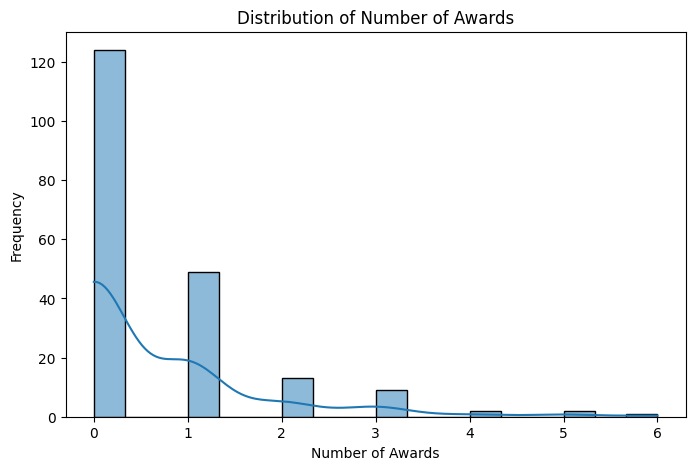

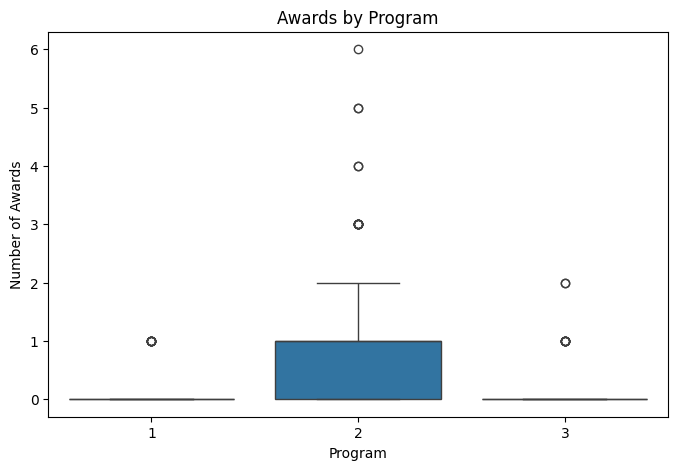


--- Poisson Regression Summary ---
                 Generalized Linear Model Regression Results                  
Dep. Variable:             num_awards   No. Observations:                  200
Model:                            GLM   Df Residuals:                      196
Model Family:                 Poisson   Df Model:                            3
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -182.75
Date:                Tue, 19 May 2026   Deviance:                       189.45
Time:                        05:54:06   Pearson chi2:                     212.
No. Iterations:                     5   Pseudo R-squ. (CS):             0.3881
Covariance Type:            nonrobust                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept   

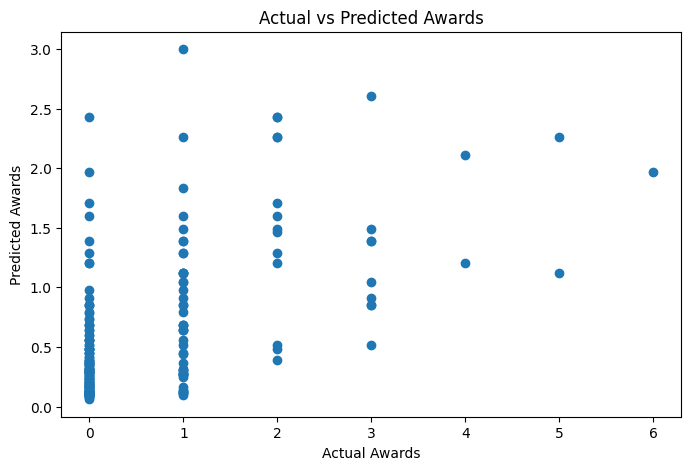


--- Interpretation ---

1. Poisson regression is used for
   count data analysis.

2. IRR > 1:
   Predictor increases expected count.

3. IRR < 1:
   Predictor decreases expected count.

4. If p-value < 0.05:
   Predictor is statistically significant.

5. The variable 'math' shows how
   math score affects the expected
   number of awards.


Analysis Complete.


In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf

import matplotlib.pyplot as plt
import seaborn as sns


# 1. Load Dataset

df = pd.read_csv('poisson_sim.csv')

# 2. Display First Rows

print("\n--- First 5 Observations ---")
print(df.head())

# 3. Summary Statistics

print("\n--- Summary Statistics ---")
print(df.describe(include='all'))

# 4. Data Visualization

# Distribution of Awards
plt.figure(figsize=(8,5))

sns.histplot(
    df['num_awards'],
    kde=True
)

plt.title('Distribution of Number of Awards')
plt.xlabel('Number of Awards')
plt.ylabel('Frequency')

plt.show()

# Awards by Program
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='prog',
    y='num_awards'
)

plt.title('Awards by Program')
plt.xlabel('Program')
plt.ylabel('Number of Awards')

plt.show()

# 5. Fit Poisson Regression Model

model = smf.glm(

    formula='num_awards ~ C(prog) + math',

    data=df,

    family=sm.families.Poisson()

).fit()

# 6. Model Summary

print("\n--- Poisson Regression Summary ---")
print(model.summary())

# 7. Incident Rate Ratios (IRR)

irr = np.exp(model.params)

print("\n--- Incident Rate Ratios (IRR) ---")
print(irr)

# 8. Confidence Intervals for IRR

conf_int = np.exp(model.conf_int())

conf_int.columns = [

    'Lower 95% CI',
    'Upper 95% CI'

]

irr_table = pd.concat(

    [irr, conf_int],
    axis=1

)

irr_table.columns = [

    'IRR',
    'Lower 95% CI',
    'Upper 95% CI'

]

print("\n--- IRR with Confidence Intervals ---")
print(irr_table)

# 9. Predicted Values

df['Predicted_Awards'] = model.predict(df)

print("\n--- Predicted Values ---")
print(df[['num_awards', 'Predicted_Awards']].head())

# 10. Actual vs Predicted Plot

plt.figure(figsize=(8,5))

plt.scatter(

    df['num_awards'],
    df['Predicted_Awards']

)

plt.xlabel('Actual Awards')
plt.ylabel('Predicted Awards')

plt.title('Actual vs Predicted Awards')

plt.show()

# 11. Interpretation

print("\n--- Interpretation ---")

print("""
1. Poisson regression is used for
   count data analysis.

2. IRR > 1:
   Predictor increases expected count.

3. IRR < 1:
   Predictor decreases expected count.

4. If p-value < 0.05:
   Predictor is statistically significant.

5. The variable 'math' shows how
   math score affects the expected
   number of awards.
""")

print("\nAnalysis Complete.")

problem 7:
School administrators study the attendance behavior (number of days absent) as a function of program type (e.g., vocational, general, or academic) and standardized math scores. The data set is taken from https://stats.idre.ucla.edu/stat/data/nb_data.csv. Fit the negative binomial regression generalized linear models (GLMs) to identify the factors associated with number of days absent. Interpret the result.

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf

# 1. Load the dataset from the URL
url = "https://stats.idre.ucla.edu/stat/stata/dae/nb_data.dta"
df = pd.read_stata(url)

# 2. Fit the Negative Binomial GLM
# 'daysabs' is the response; 'prog' is categorical; 'math' is continuous
# The Negative Binomial family is used to handle overdispersion
model = smf.glm('daysabs ~ C(prog) + math', data=df,
                family=sm.families.NegativeBinomial()).fit()

# 3. Model Summary
print(model.summary())

# 4. Calculate Incident Rate Ratios (IRR) for Interpretation
# IRR = exp(coefficient)
irr = np.exp(model.params)
print("\n--- Incident Rate Ratios (IRR) ---")
print(irr)

# 5. Check for Overdispersion (Mean vs Variance)
print(f"\nMean of daysabs: {df['daysabs'].mean():.4f}")
print(f"Variance of daysabs: {df['daysabs'].var():.4f}")

                 Generalized Linear Model Regression Results                  
Dep. Variable:                daysabs   No. Observations:                  314
Model:                            GLM   Df Residuals:                      310
Model Family:        NegativeBinomial   Df Model:                            3
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -865.68
Date:                Tue, 19 May 2026   Deviance:                       350.98
Time:                        05:55:35   Pearson chi2:                     331.
No. Iterations:                     6   Pseudo R-squ. (CS):             0.1926
Covariance Type:            nonrobust                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          2.6150      0.200     13.

/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


problem 8:The state wildlife biologists want to model how many fish are being caught by fishermen at a state park. Visitors are asked how long they stayed, how many people were in the group, whether there were children in the group, and how many fish were caught. Some visitors do not fish, but there is no data on whether a person fished or not. Some visitors who did fish did not catch any fish, so there are excess zeros in the data because of the people that did not fish. The data set is taken from https://stats.idre.ucla.edu/stat/data/fish.csv. Fit the Zero-Inflated Poisson regression generalized linear model (GLMs) to identify the factors associated with the number of fish caught. Interpret the result.

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.discrete.count_model import ZeroInflatedPoisson

# 1. Load the dataset
df = pd.read_csv('fish.csv')

# 2. Define variables
y = df['count']
# Count part: Predictors for the number of fish caught
X = df[['camper', 'persons', 'child']]
X = sm.add_constant(X)

# Inflation part: Predictors for whether they didn't fish at all (Always Zero)
X_infl = df[['child', 'persons']]
X_infl = sm.add_constant(X_infl)

# 3. Fit the Zero-Inflated Poisson (ZIP) model
# inflation='logit' handles the probability of being a structural zero
model = ZeroInflatedPoisson(y, X, exog_infl=X_infl, inflation='logit').fit()

# 4. Display Results
print(model.summary())

# Calculate Interpretative Metrics
print("\n--- Odds Ratios (Probability of being a Non-Fisher) ---")
print(np.exp(model.params.filter(like='inflate')))

print("\n--- Incident Rate Ratios (Effect on Catch Count) ---")
print(np.exp(model.params.drop(model.params.filter(like='inflate').index)))

Optimization terminated successfully.
         Current function value: 3.022141
         Iterations: 23
         Function evaluations: 25
         Gradient evaluations: 25
                     ZeroInflatedPoisson Regression Results                    
Dep. Variable:                   count   No. Observations:                  250
Model:             ZeroInflatedPoisson   Df Residuals:                      246
Method:                            MLE   Df Model:                            3
Date:                 Tue, 19 May 2026   Pseudo R-squ.:                  0.3296
Time:                         05:58:14   Log-Likelihood:                -755.54
converged:                        True   LL-Null:                       -1127.0
Covariance Type:             nonrobust   LLR p-value:                1.007e-160
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
inflate_const       

problem 9:
The state wildlife biologists want to model how many fish are being caught by fishermen at a state park. Visitors are asked how long they stayed, how many people were in the group, whether there were children in the group, and how many fish were caught. Some visitors do not fish, but there is no data on whether a person fished or not. Some visitors who did fish did not catch any fish, so there are excess zeros in the data because of the people that did not fish. The data set is taken from https://stats.idre.ucla.edu/stat/data/fish.csv. Fit the Zero-Inflated Binomial regression generalized linear model (GLMs) to identify the factors associated with the number of awards earned by students at one high school. Interpret the result.




In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.discrete.count_model import ZeroInflatedPoisson

# 1. Load the dataset
df = pd.read_csv('fish.csv')

# 2. Setup the Variables
# Count Part (Poisson): Predicts the number of fish caught
X_count = df[['camper', 'persons', 'child']]
X_count = sm.add_constant(X_count)

# Inflation Part (Logit): Predicts the probability of being a 'non-fisher'
X_inflate = df[['child', 'persons']]
X_inflate = sm.add_constant(X_inflate)

# 3. Fit the Zero-Inflated Poisson (ZIP) Model
zip_model = ZeroInflatedPoisson(df['count'], X_count, exog_infl=X_inflate).fit()

# 4. Display Summary and Interpretive Metrics
print(zip_model.summary())

# Calculate Odds Ratios (OR) and Incident Rate Ratios (IRR)
params = zip_model.params
print("\n--- Odds Ratios (Non-Fisher Probability) ---")
print(np.exp(params[params.index.str.contains('inflate')]))

print("\n--- Incident Rate Ratios (Catch Rate) ---")
print(np.exp(params[~params.index.str.contains('inflate')]))

Optimization terminated successfully.
         Current function value: 3.022141
         Iterations: 23
         Function evaluations: 25
         Gradient evaluations: 25
                     ZeroInflatedPoisson Regression Results                    
Dep. Variable:                   count   No. Observations:                  250
Model:             ZeroInflatedPoisson   Df Residuals:                      246
Method:                            MLE   Df Model:                            3
Date:                 Tue, 19 May 2026   Pseudo R-squ.:                  0.3296
Time:                         06:09:13   Log-Likelihood:                -755.54
converged:                        True   LL-Null:                       -1127.0
Covariance Type:             nonrobust   LLR p-value:                1.007e-160
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
inflate_const       

Problem 10:A study of length of hospital stay, in days, as a function of age, kind of health insurance and whether or not the patient died while in the hospital. Length of hospital stay is recorded as a minimum of at least one day. The data set is taken from https://stats.idre.ucla.edu/stat/data/ztp.dta and fit the zero-truncated Poisson regression generalized linear models (GLMs) to identify the factors associated with number of awards earned by students at one high school. Interpret the result.

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
import pyreadstat # Import pyreadstat

# 1. Load the dataset
# Note: ztp.dta is a Stata file. If pandas.read_stata fails due to versioning,
# ensure the file is converted to CSV first.

# Read the Stata file using pyreadstat
df_stata, meta = pyreadstat.read_dta('ztp.dta')
# Save it to a temporary CSV file
df_stata.to_csv('ztp_temp.csv', index=False)
# Load the data from the CSV file
df = pd.read_csv('ztp_temp.csv')

# 2. Fit the Negative Binomial GLM
# Predictors: age, hmo (insurance type), died (binary outcome)
# Response: stay (number of days)
model = smf.glm('stay ~ age + hmo + died', data=df,
                family=sm.families.NegativeBinomial()).fit()

# 3. Model Summary
print(model.summary())

# 4. Calculate Incident Rate Ratios (IRR)
# IRR = exp(coefficient)
irr = np.exp(model.params)
print("\n--- Incident Rate Ratios (IRR) ---")
print(irr)

                 Generalized Linear Model Regression Results                  
Dep. Variable:                   stay   No. Observations:                 1493
Model:                            GLM   Df Residuals:                     1489
Model Family:        NegativeBinomial   Df Model:                            3
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -4955.3
Date:                Tue, 19 May 2026   Deviance:                       827.73
Time:                        06:17:12   Pearson chi2:                     938.
No. Iterations:                     5   Pseudo R-squ. (CS):            0.01154
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      2.4378      0.091     26.920      0.0

/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


In [ ]:
!pip install pyreadstat

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 23.8 MB/s eta 0:00:00


Problem 11:
A study of length of hospital stay, in days, as a function of age, kind of health insurance (HMO), and whether or not the patient died while in the hospital. Length of hospital stay is recorded as a minimum of at least one day. The data set is taken from https://stats.idre.ucla.edu/stat/data/ztp.dta. Fit the zero-truncated negative binomial regression generalized linear models (GLMs) to identify the factors associated with length of hospital stay. Interpret the result.

In [ ]:
# Custom ZTNB Class
class ZTNB(GenericLikelihoodModel):
    def loglike(self, params):
        beta = params[:-1]
        alpha = params[-1]
        if alpha <= 0: return -np.inf
        mu = np.exp(np.dot(self.exog, beta))
        size = 1 / alpha
        prob = size / (size + mu)
        ll_nb = nbinom.logpmf(self.endog, size, prob)
        p0 = (1 + alpha * mu) ** (-1/alpha)
        return np.sum(ll_nb - np.log(1 - p0))

df11 = pd.read_csv("ztp_temp.csv")
X11 = sm.add_constant(df11[['age', 'hmo', 'died']])
# Using GLM start params for stability
start_p = np.append(sm.GLM(df11['stay'], X11, family=sm.families.NegativeBinomial()).fit().params.values, 1.0)
model11 = ZTNB(df11['stay'], X11).fit(start_params=start_p)
print(model11.summary())
print("\n--- IRRs ---")
print(np.exp(model11.params[:-1]))

/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


Optimization terminated successfully.
         Current function value: 3.185050
         Iterations: 248
         Function evaluations: 408
                                 ZTNB Results                                 
Dep. Variable:                   stay   Log-Likelihood:                -4755.3
Model:                           ZTNB   AIC:                             9521.
Method:            Maximum Likelihood   BIC:                             9547.
Date:                Tue, 19 May 2026                                         
Time:                        06:19:22                                         
No. Observations:                1493                                         
Df Residuals:                    1489                                         
Df Model:                           3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:2748: UserWarning: df_model + k_constant + k_extra differs from k_params
  warnings.warn("df_model + k_constant + k_extra "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:2752: UserWarning: df_resid differs from nobs - k_params
  warnings.warn("df_resid differs from nobs - k_params")
